# Single-cell RNA-seq preprocessing and analysis (sex-chimeric dataset)

This notebook performs end-to-end preprocessing and analysis of the sex-chimeric single-cell RNA-seq dataset, including:

- **Loading 10x Genomics count matrices** for all samples.
- **Merging samples and basic quality control (QC)** on cells and genes.
- **Normalization, dimensionality reduction, batch integration, and clustering** using Scanpy and Harmony.
- **Sex label assignment** using precomputed CellSexID predictions.
- **Macrophage subsetting and reclustering** to obtain higher-resolution macrophage populations.
- **Differential expression and downstream analyses** for macrophage subpopulations.


In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
import pandas as pd
import scanpy as sc
import os
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.colors import LinearSegmentedColormap
seed = 10
np.random.seed(seed)
sc.settings.verbosity = 3
import scrublet as scr
sc.settings.set_figure_params(dpi=80, facecolor='white')
results_file = './sex_chimeric.h5ad'  # the file that will store the analysis results

## Load 10x count matrices

Read filtered 10x Genomics feature-barcode matrices for all samples and store each sample as a separate AnnData object with basic metadata.

In [ ]:
# WT Recipient Day1
WR1_WT_WT_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/WT_to_WT_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR1_WT_WT_sample2 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/WT_to_WT_sample2/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR1_WT_WT_sample3 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/WT_to_WT_sample3/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR1_WT_WT_sample4 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/WT_to_WT_sample4/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)

WR1_mdx_WT_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/mdx_to_WT_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR1_mdx_WT_sample2 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/mdx_to_WT_sample2/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
WR1_mdx_WT_sample3 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/mdx_to_WT_sample3/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
WR1_mdx_WT_sample4 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/mdx_to_WT_sample4/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
WR1_mdx_WT_sample5 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day1/outs/per_sample_outs/mdx_to_WT_sample5/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)                 

In [ ]:
# WT Recipient Day2
WR2_WT_WT_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/WT_to_WT_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR2_WT_WT_sample2 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/WT_to_WT_sample2/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR2_WT_WT_sample3 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/WT_to_WT_sample3/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR2_WT_WT_sample4 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/WT_to_WT_sample4/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)

WR2_mdx_WT_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/mdx_to_WT_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
WR2_mdx_WT_sample2 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/mdx_to_WT_sample2/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
WR2_mdx_WT_sample3 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/mdx_to_WT_sample3/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
WR2_mdx_WT_sample4 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/mdx_to_WT_sample4/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
WR2_mdx_WT_sample5 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/WT_Recipient_Day2/outs/per_sample_outs/mdx_to_WT_sample5/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)                 

In [ ]:
# mdx Recipient Day1
MR1_WT_mdx_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/mdx_Recipient_Day1/outs/per_sample_outs/WT_to_mdx_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)

MR1_mdx_mdx_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/mdx_Recipient_Day1/outs/per_sample_outs/mdx_to_mdx_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)           
MR1_mdx_mdx_sample2 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/mdx_Recipient_Day1/outs/per_sample_outs/mdx_to_mdx_sample2/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)     

In [ ]:
# mdx Recipient Day2
MR2_WT_mdx_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/mdx_Recipient_Day2/outs/per_sample_outs/WT_to_mdx_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
MR2_WT_mdx_sample2 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/mdx_Recipient_Day2/outs/per_sample_outs/WT_to_mdx_sample2/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)              

MR2_mdx_mdx_sample1 = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/sex_chimeric/cellranger_results/mdx_Recipient_Day2/outs/per_sample_outs/mdx_to_mdx_sample1/count/sample_filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)

In [6]:
for i,a in enumerate([WR1_WT_WT_sample1, WR1_WT_WT_sample2, WR1_WT_WT_sample3, WR1_WT_WT_sample4, WR1_mdx_WT_sample1, WR1_mdx_WT_sample2, WR1_mdx_WT_sample3, WR1_mdx_WT_sample4, WR1_mdx_WT_sample5,
                      WR2_WT_WT_sample1, WR2_WT_WT_sample2, WR2_WT_WT_sample3, WR2_WT_WT_sample4, WR2_mdx_WT_sample1, WR2_mdx_WT_sample2, WR2_mdx_WT_sample3, WR2_mdx_WT_sample4, WR2_mdx_WT_sample5,
                      MR1_WT_mdx_sample1, MR1_mdx_mdx_sample1, MR1_mdx_mdx_sample2, MR2_WT_mdx_sample1, MR2_WT_mdx_sample2, MR2_mdx_mdx_sample1]):
    a.obs['dataset']=str(i)

In [ ]:
adata_merge = WR1_WT_WT_sample1.concatenate(WR1_WT_WT_sample2, WR1_WT_WT_sample3, WR1_WT_WT_sample4, WR1_mdx_WT_sample1, WR1_mdx_WT_sample2, WR1_mdx_WT_sample3, WR1_mdx_WT_sample4, WR1_mdx_WT_sample5,
                                            WR2_WT_WT_sample1, WR2_WT_WT_sample2, WR2_WT_WT_sample3, WR2_WT_WT_sample4, WR2_mdx_WT_sample1, WR2_mdx_WT_sample2, WR2_mdx_WT_sample3, WR2_mdx_WT_sample4, WR2_mdx_WT_sample5,
                                            MR1_WT_mdx_sample1, MR1_mdx_mdx_sample1, MR1_mdx_mdx_sample2, MR2_WT_mdx_sample1, MR2_WT_mdx_sample2, MR2_mdx_mdx_sample1, batch_key='sample')

## Pre-processing and quality control

Make gene identifiers unique before computing any quality control statistics.

normalizing counts per cell
    finished (0:00:00)


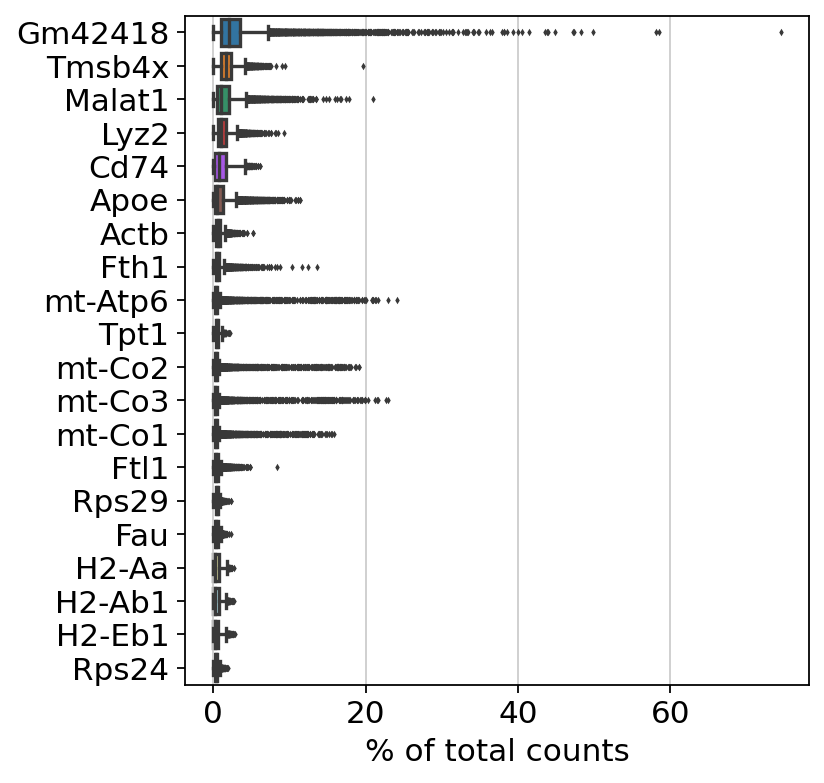

In [ ]:
adata_merge.var_names_make_unique()
# Show those genes that yield the highest fraction of counts in each single cell, across all cells.
sc.pl.highest_expr_genes(adata_merge, n_top=20, )

Filter out cells with very few detected genes and genes that are seen in only a handful of cells to remove low-information entries.

In [12]:
sc.pp.filter_cells(adata_merge, min_genes=200)
sc.pp.filter_genes(adata_merge, min_cells=3)

filtered out 139 cells that have less than 200 genes expressed
filtered out 11383 genes that are detected in less than 3 cells


In [12]:
adata_merge.var['mt'] = adata_merge.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata_merge, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
sc.pl.violin(adata_merge, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

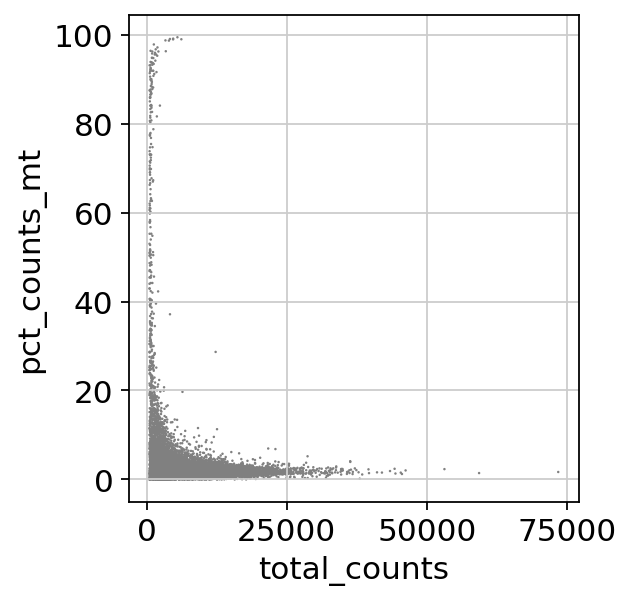

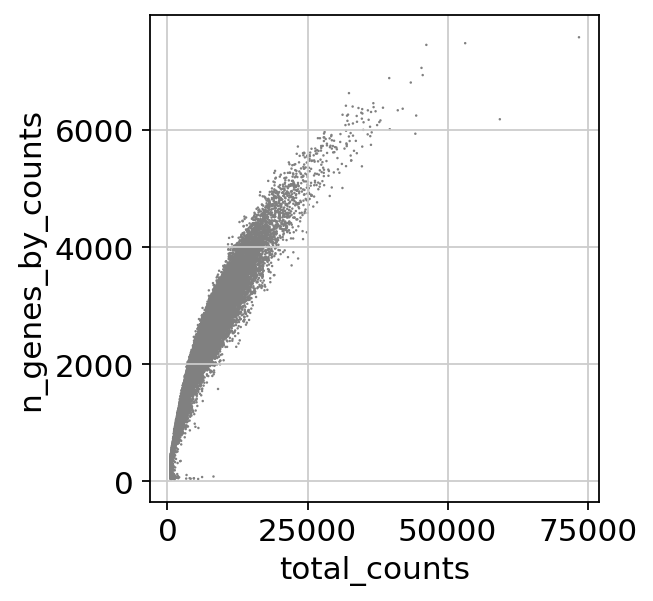

In [14]:
sc.pl.scatter(adata_merge, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata_merge, x='total_counts', y='n_genes_by_counts')

Cells with >6,200 detected genes (potential doublets) and >20% mitochondrial transcripts (compromised membrane integrity) were excluded.

In [16]:
adata_merge = adata_merge[adata_merge.obs.n_genes_by_counts < 6200, :]
adata_merge = adata_merge[adata_merge.obs.pct_counts_mt < 20, :]

Only cells expressing Ptprc/Cd45 were retained for immune-focused analysis.

In [17]:
adata_merge = adata_merge[adata_merge[:,adata_merge.var.index=='Ptprc'].X.todense() > 0,:]

Counts were normalized to 10,000 UMI/cell, log-transformed, and highly variable genes were selected (dispersion-based); the dataset was subset to these genes for downstream analysis.

In [15]:
sc.pp.normalize_total(adata_merge, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


In [16]:
sc.pp.log1p(adata_merge)

In [ ]:
sc.pp.highly_variable_genes(adata_merge, min_mean=0.0125, max_mean=3, min_disp=0.5)

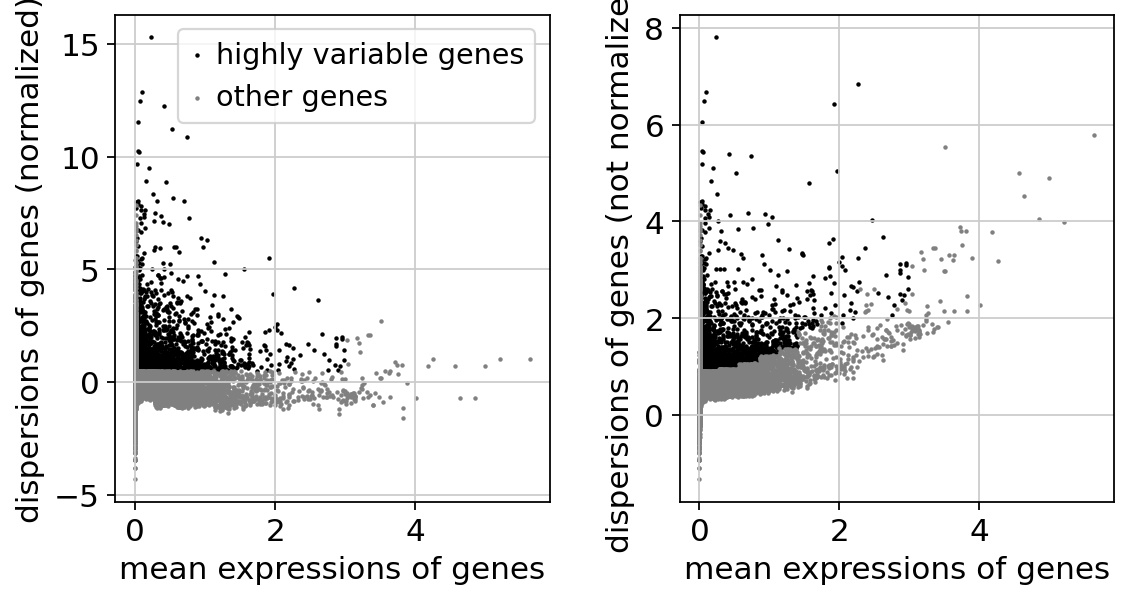

In [22]:
sc.pl.highly_variable_genes(adata_merge)

In [ ]:
adata_merge.raw = adata_merge
adata_merge.write('./sex_chimeric_gender.h5ad')

In [26]:
adata_merge = adata_merge[:, adata_merge.var.highly_variable]

In [28]:
sc.pp.regress_out(adata_merge, ['total_counts', 'pct_counts_mt'])

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:01:24)


In [29]:
sc.pp.scale(adata_merge, max_value=10)

In [30]:
sc.tl.pca(adata_merge, svd_solver='arpack')

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:03)


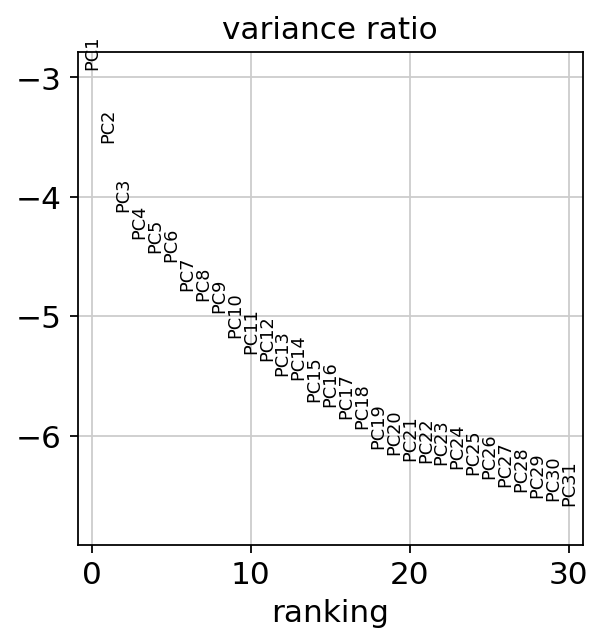

In [32]:
sc.pl.pca_variance_ratio(adata_merge, log=True)

In [ ]:
adata_merge.write(results_file)

Use Harmony to remove batch effects across datasets

In [ ]:
adata_H = adata_merge.copy()
sc.external.pp.harmony_integrate(adata_H,key='dataset',adjusted_basis='X_pca')
sc.pp.neighbors(adata_H, n_neighbors=10, n_pcs=40) #Compute the neighborhood graph of cells using the PCA representation
sc.tl.umap(adata_H) #Embed the neighborhood graph using UMAP.

### Select Leiden clustering resolution

Evaluate a range of Leiden resolutions using silhouette scores to choose a stable clustering for downstream analysis.

running Leiden clustering
    finished: found 7 clusters and added
    'leiden_0.1', the cluster labels (adata.obs, categorical) (0:00:02)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 13 clusters and added
    'leiden_0.4', the cluster labels (adata.obs, categorical) (0:00:02)
running Leiden clustering
    finished: found 15 clusters and added
    'leiden_0.5', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 15 clusters and added
    'leiden_0.6', the cluster labels (adata.obs, categorical) (0:00:03)
running Leiden clustering
    finished: found 17 clusters and added
    'leiden_0.7', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clusteri

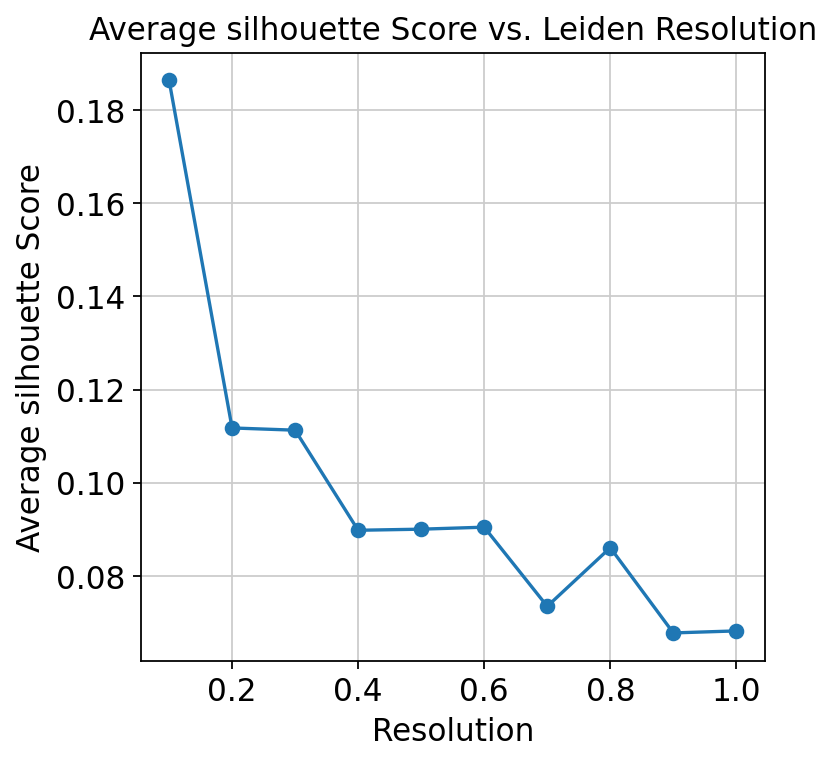

Best resolution by silhouette score: 0.1


In [ ]:
resolutions = [0.1,0.2, 0.3,0.4, 0.5,0.6,0.7, 0.8, 0.9,1.0]
silhouette_scores = []

for res in resolutions:
    key = f'leiden_{res}'
    sc.tl.leiden(adata_H, resolution=res, key_added=key)
    
    labels = adata_H.obs[key].values
    score = silhouette_score(adata_H.obsm['X_pca'], labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(resolutions, silhouette_scores, marker='o')
plt.xlabel('Resolution')
plt.ylabel('Average silhouette Score')
plt.title('Average silhouette Score vs. Leiden Resolution')
plt.show()

In [ ]:
sc.tl.leiden(adata_H, resolution = 0.6)

In [ ]:
replacement_dict = {'0': 'WT_WT', '1': 'WT_WT', '2': 'WT_WT', '3': 'WT_WT',
                    '4': 'mdx_WT', '5': 'mdx_WT', '6': 'mdx_WT', '7': 'mdx_WT', '8': 'mdx_WT',
                    '9': 'WT_WT', '10': 'WT_WT', '11': 'WT_WT', '12': 'WT_WT',
                    '13': 'mdx_WT', '14': 'mdx_WT', '15': 'mdx_WT', '16': 'mdx_WT', '17': 'mdx_WT',
                    '18': 'WT_mdx', '19': 'mdx_mdx', '20': 'mdx_mdx',
                    '21': 'WT_mdx', '22': 'WT_mdx', '23': 'mdx_mdx'}

In [11]:
new_cluster_names = ["Macrophage K0", "Macrophage K1","Macrophage K2",
                     "Macrophage K3","Macrophage K4", "Macrophage K5",
                     "Macrophage K6", "Macrophage K7", "Macrophage K8",
                     "Neutrophil K13", "Macrophage K9", "Macrophage K10",
                     "B cell K14", "Macrophage K11", "Macrophage K12"]
adata_H.rename_categories('leiden', new_cluster_names)
cluster_color_dict = dict(zip(new_cluster_names, adata_H.uns["leiden_colors"]))

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


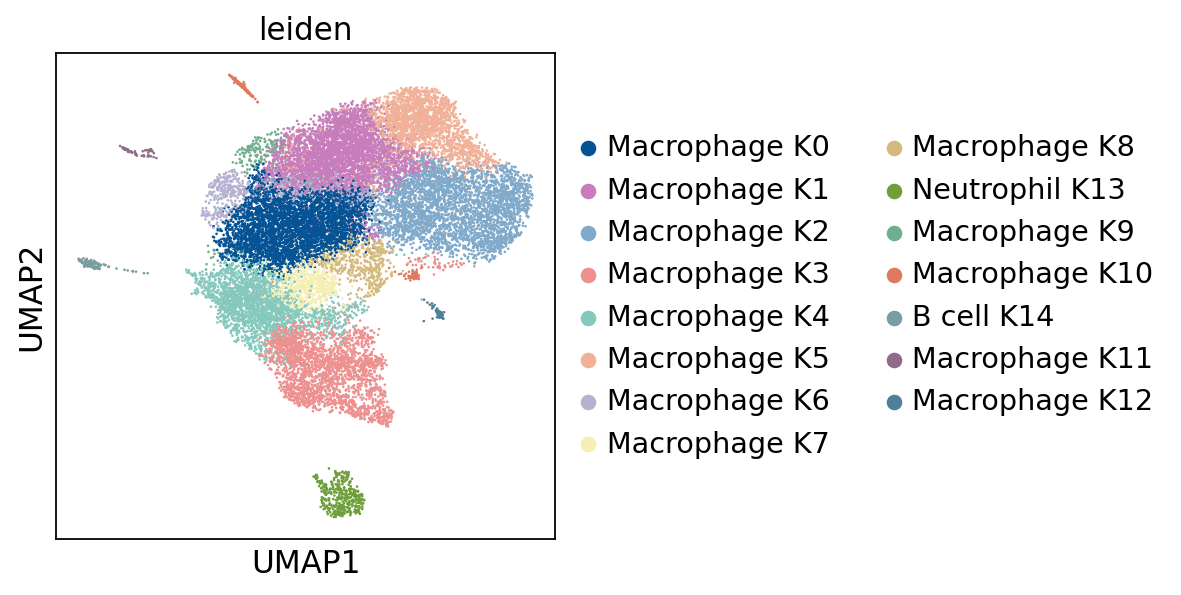

In [ ]:
cluster_color_dict = {
    "Macrophage K0": "#055394","Macrophage K1": "#C77DBB","Macrophage K2": "#80A9CA",
    "Macrophage K3": "#ED9090","Macrophage K4": "#85C8BD", "Macrophage K5": "#F1B198",
    "Macrophage K6": "#B5B1D1","Macrophage K7": "#F5EFB4", "Macrophage K8": "#D6B97C",
    "Macrophage K9": "#6FAF8E","Macrophage K10": "#E07A5F", "Macrophage K11": "#8E6C8A",
    "Macrophage K12": "#4E8098","Neutrophil K13":"#6E9F3B","B cell K14":"#7A9E9F" }
sc.pl.umap(adata_H, color=['leiden'], use_raw=False, palette=cluster_color_dict,) 

In [ ]:
adata_H.write(results_file)

## Assign predicted sex labels

Merge CellSexID predictions into the integrated object and annotate each cell as male or female based on its predicted label.

In [ ]:
results_file = './sex_chimeric.h5ad'  # the file that will store the analysis results
adata_H = sc.read(results_file)
adata_merge = sc.read("./sex_chimeric_gender.h5ad")
adata_merge.obs.index
adata_H.obs.index
same_order = all(adata_merge.obs.index == adata_H.obs.index)
file_path = './CellSexID_pred/predicted_labels_dataset_1.csv'
WT_WT_df = pd.read_csv(file_path)
file_path = './CellSexID_pred/predicted_labels_dataset_2.csv'
mdx_WT_df = pd.read_csv(file_path)
file_path = './CellSexID_pred/predicted_labels_dataset_3.csv'
WT_mdx_df = pd.read_csv(file_path)
file_path = './CellSexID_pred/predicted_labels_dataset_4.csv'
mdx_mdx_df = pd.read_csv(file_path)
adata_H.obs.drop(columns=['pred_sex'], inplace=True)
adata_H.obs.loc[adata_H.obs['WT_sum_cat'] == 'WT_WT', 'pred_sex'] = WT_WT_df["Prediction"].values
adata_H.obs.loc[adata_H.obs['WT_sum_cat'] == 'mdx_WT', 'pred_sex'] = mdx_WT_df["Prediction"].values
adata_H.obs.loc[adata_H.obs['WT_sum_cat'] == 'WT_mdx', 'pred_sex'] = WT_mdx_df["Prediction"].values
adata_H.obs.loc[adata_H.obs['WT_sum_cat'] == 'mdx_mdx', 'pred_sex'] = mdx_mdx_df["Prediction"].values
adata_H.obs['pred_sex'] = adata_H.obs['pred_sex'].apply(lambda x: 'female' if x < 0.5 else 'male')

/mnt/data/jiahui/anaconda3/envs/omicverse/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/mnt/data/jiahui/anaconda3/envs/omicverse/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


## Subset to macrophages and recompute clustering

Remove non-macrophage clusters, subset to macrophage cells, and rerun the clustering workflow for higher-resolution macrophage populations.

### Filter low-cell clusters

Remove clusters with few cells so that downstream analyses use only robust populations.

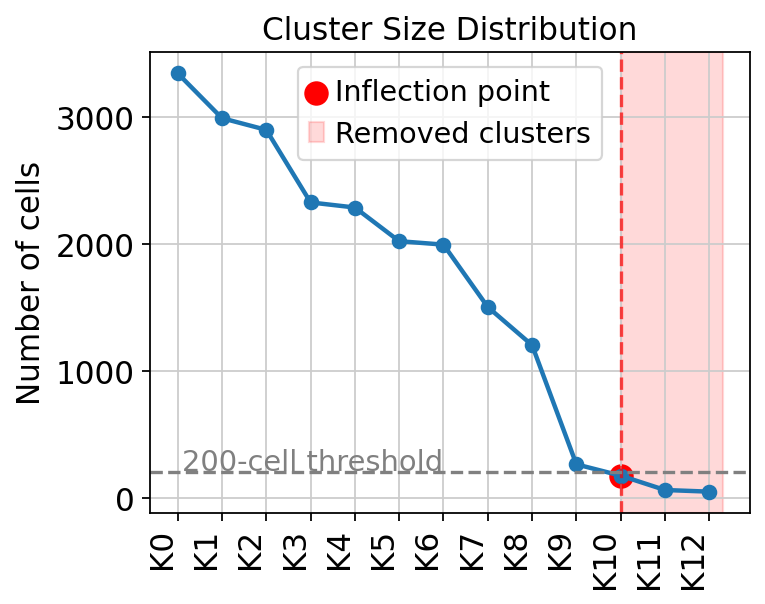

In [ ]:
sc.set_figure_params(figsize=(5, 5))
adata_M = adata_H[adata_H.obs['leiden'].str.startswith("Macrophage")].copy()
cluster_sizes_raw = (adata_M.obs['leiden_M'].value_counts().sort_index())
cluster_sizes = {k.replace("C", "K"): int(v) for k, v in cluster_sizes_raw.items()}
clusters = list(cluster_sizes.keys())
sizes = np.array(list(cluster_sizes.values()))
inflection_x = clusters.index("K10")
inflection_y = cluster_sizes["K10"]
plt.figure(figsize=(5, 4))
plt.plot(clusters, sizes, marker='o', linewidth=2)

plt.scatter(inflection_x, inflection_y, color='red', s=100, label='Inflection point')
plt.axvline(x=inflection_x, color='red', linestyle='--', alpha=0.7)

del_start = clusters.index("K10")
del_end = clusters.index("K12")
plt.axvspan(del_start, del_end + 0.3, color='red', alpha=0.15, label='Removed clusters')
plt.axhline(y=200, color='gray', linestyle='--', linewidth=1.5)
plt.text(0.1, 200 + 20, "200-cell threshold", color='gray', fontsize=13, ha='left')
plt.xlabel("")
plt.xticks(rotation=90, ha='right')
plt.ylabel("Number of cells")
plt.title("Cluster Size Distribution")
plt.legend()
plt.tight_layout()
plt.show()


/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


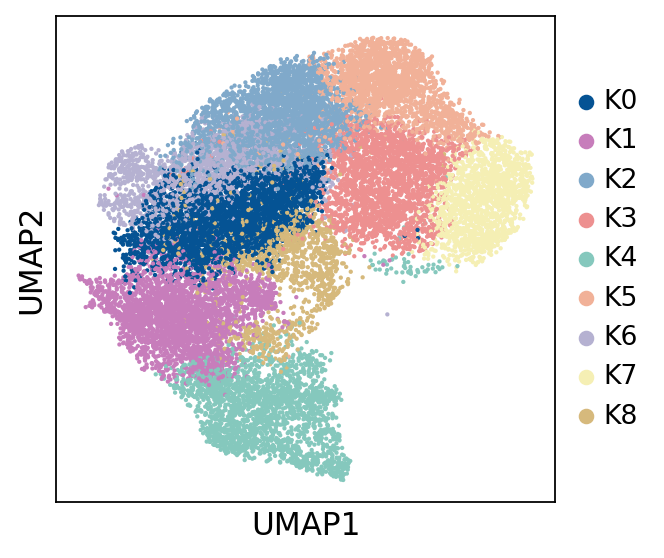

In [ ]:
sc.set_figure_params(figsize=(4, 4))
cluster_color_dict = {
    "K0": "#055394","K1": "#C77DBB","K2": "#80A9CA","K3": "#ED9090", "K4": "#85C8BD",
    "K5": "#F1B198","K6": "#B5B1D1","K7": "#F5EFB4","K8": "#D6B97C","K9": "#6FAF8E",
    "10": "#E07A5F","11": "#8E6C8A","12": "#4E8098"}

sc.tl.leiden(adata_M, resolution = 0.6, key_added='leiden_M')
sc.pl.umap(adata_M, color=['leiden_M'], use_raw=False)
adata_M.obs['leiden_M_K'] = adata_M.obs['leiden_M'].astype(str).apply(lambda x: f"K{x}")
exclude_clusters = ["K9","K10", "K11", "K12"]
adata_M_plot = adata_M[~adata_M.obs['leiden_M_K'].isin(exclude_clusters)].copy()
sc.pl.umap(adata_M_plot, color='leiden_M_K',palette=cluster_color_dict,title = "",
           legend_loc='right margin', frameon=True, legend_fontsize=12, legend_fontweight='semibold',size = 15,save = '_b4_split.pdf')

### Refine fibrotic-associated macrophage subcluster

Among the remaining macrophage clusters, one showed elevated Spp1, Lgals3, and Fabp5 (fibrotic-associated in dystrophic muscle) and internal transcriptional heterogeneity; it was refined with Leiden resolution 0.12 restricted to this population.

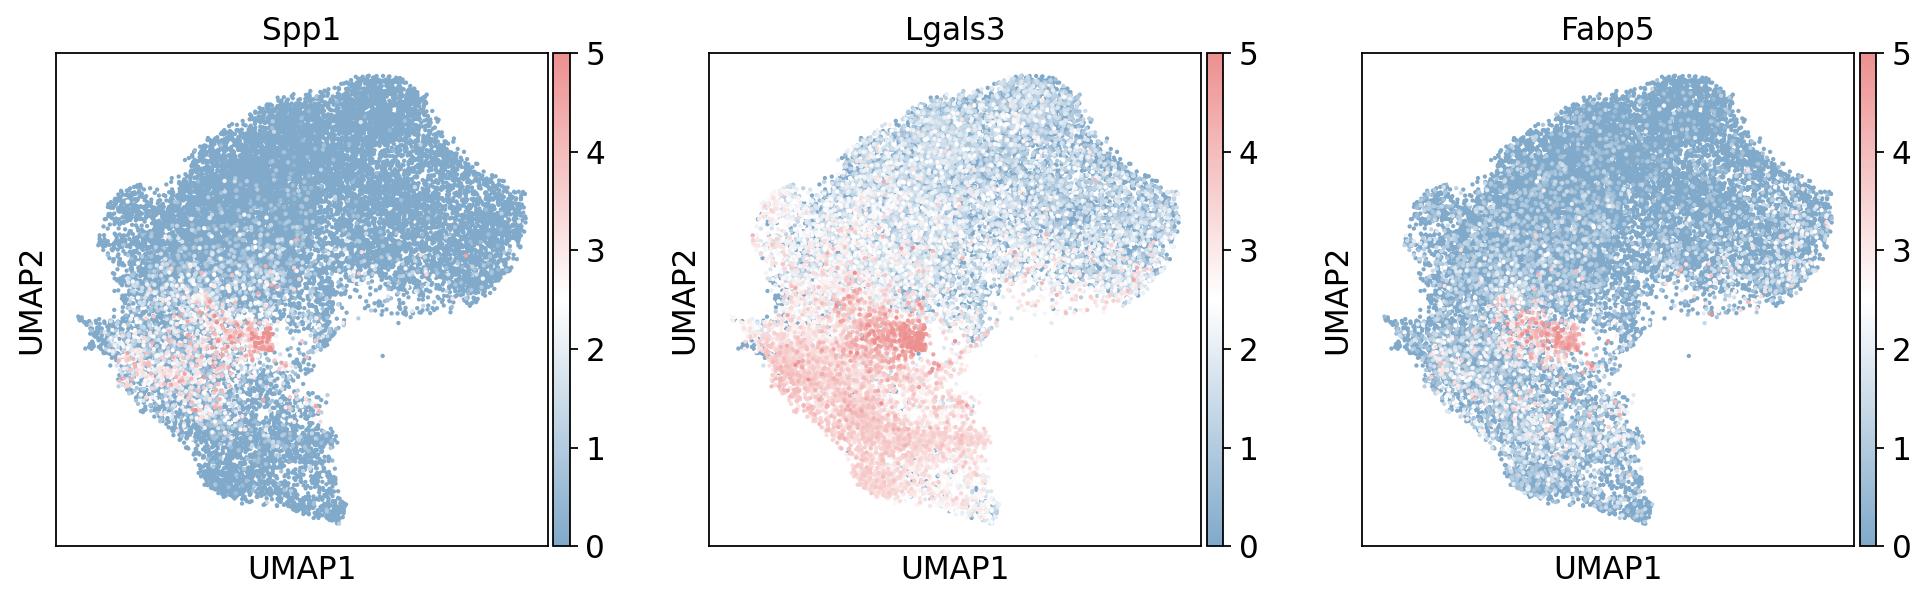

In [ ]:
gene_cmap = LinearSegmentedColormap.from_list(
    "gene_gradient",
    [ "#80A9CA","white","#ED9090"]
)
sc.pl.umap(adata_M_plot, color=['Spp1',"Lgals3","Fabp5"],cmap=gene_cmap,title=["Spp1", "Lgals3", "Fabp5"],vmax=5,
           legend_loc='right margin', frameon=True, legend_fontsize=12, legend_fontweight='semibold',size = 15,save = '_diseasegenes.pdf')

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


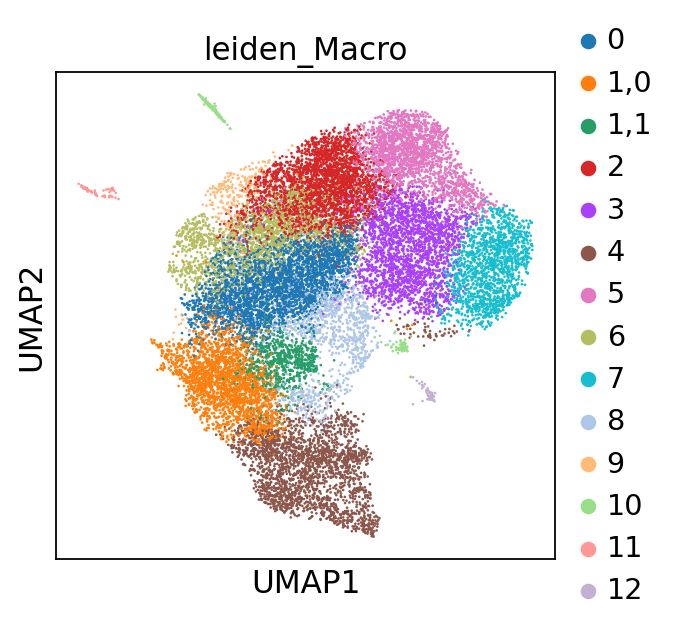

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


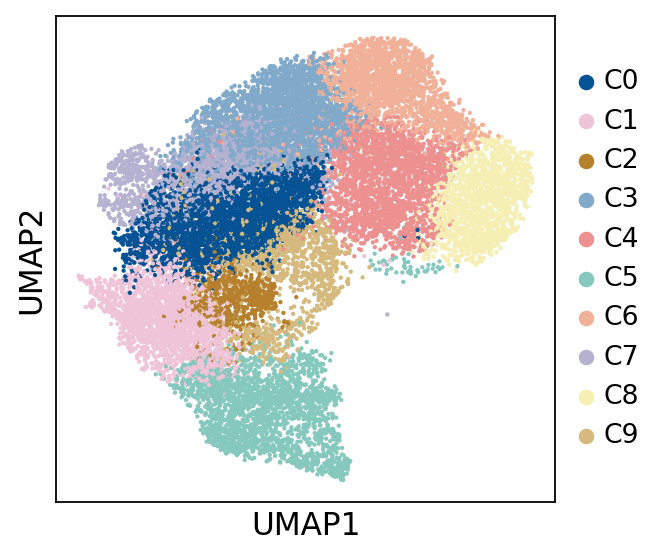

In [ ]:
sc.tl.leiden(adata_M, resolution=0.12,key_added="leiden_Macro", restrict_to=('leiden_M', ['1']))
sc.pl.umap(adata_M, color=["leiden_Macro"])
labels = adata_M.obs['leiden_Macro'].astype(str)

uniq_sorted = sorted(labels.unique(),key=lambda x: tuple(map(int, x.split(','))))

mapping = {lab: f"C{i}" for i, lab in enumerate(uniq_sorted)}

adata_M.obs['leiden_Macro_C'] = labels.map(mapping)
keep = [f"C{i}" for i in range(10)]
adata_M_plot = adata_M[
    adata_M.obs['leiden_Macro_C'].isin(keep)
].copy()

sc.pl.umap(adata_M_plot, color='leiden_Macro_C',palette=cluster_color_dict,title = "",
           legend_loc='right margin', frameon=True, legend_fontsize=12, legend_fontweight='semibold',size = 15,save = '_after_split.pdf')

In [ ]:
adata_M.write('./sex_chimeric_only_Macro.h5ad')

## Differential expression and pathway enrichment analysis

Identify differentially expressed genes between macrophage subpopulations and perform pathway enrichment analysis on the resulting gene sets. Mouse GO and Reactome gene sets were obtained from [here](https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Mm/).

In [ ]:
sc.settings.verbosity = 2  # reduce the verbosity
adata_M_filtered = adata_M.copy()
sc.tl.rank_genes_groups(adata_M_filtered, 'leiden_Macro', method='wilcoxon')
sc.pl.rank_genes_groups(adata_M_filtered, n_genes=25, sharey=False)
demo = pd.DataFrame(adata_M_filtered.uns['rank_genes_groups']['names']).head(100)
demo.to_csv('./top100_genes_sex_chermic_10cluster.csv', index=False)

In [ ]:
sc.set_figure_params(figsize=(4, 4))
chosen_cluster = 'Macrophage C9'
adata_M_filtered = adata_M[adata_M.obs['leiden_Macro'] != 'Macrophage C10'].copy()
sc.tl.rank_genes_groups(adata_M_filtered, 'leiden_Macro',groups = [chosen_cluster],method='wilcoxon')
sc.pl.rank_genes_groups(adata_M_filtered, groups = [chosen_cluster], n_genes=25)
result = adata_M_filtered.uns['rank_genes_groups']
num_clusters = adata_M_filtered.obs['leiden_Macro'].nunique()
print(f"Total number of clusters: {num_clusters}")

groups = result['names'].dtype.names
subet_df = pd.DataFrame({group + '_' + key[:]: result[key][group]
                        for group in groups for key in ['names', 'scores', 'pvals','pvals_adj','logfoldchanges']})
subet_df.to_csv('./pathway/cluster_vs_rest/{0}_gene_marker_10cluster.csv'.format(chosen_cluster), index=False)

In [ ]:
csv_go = "./pathway/cluster_vs_rest/{0}_gene_marker_10cluster.csv".format(chosen_cluster)
df_go = pd.read_csv(csv_go)
df_top_go = df_go.nlargest(100, '{0}_scores'.format(chosen_cluster))
df_genes_go = df_top_go['{0}_names'.format(chosen_cluster)].values.tolist()
print(len(df_genes_go))
print(df_genes_go[:10])
if df_genes_go:
    enr_GOBP_up = gp.enrichr(gene_list=df_genes_go,
                             gene_sets=['./m5.go.v2023.2.Mm.symbols.gmt'],
                             outdir=None)
    df_go_res = pd.DataFrame(enr_GOBP_up.res2d)
    df_go_res['Source'] = 'GO'

csv_reactome = "./pathway/cluster_vs_rest/{0}_gene_marker_10cluster.csv".format(chosen_cluster)
df_reactome = pd.read_csv(csv_reactome)
df_top_reactome = df_reactome.nlargest(100, '{0}_scores'.format(chosen_cluster))
df_genes_reactome = df_top_reactome['{0}_names'.format(chosen_cluster)].values.tolist()
print(len(df_genes_reactome))

if df_genes_reactome:
    enr_Reactome_up = gp.enrich(gene_list=df_genes_reactome,
                                gene_sets=['./m2.cp.reactome.v2023.2.Mm.symbols.gmt'],
                                outdir=None)
    df_reactome_res = pd.DataFrame(enr_Reactome_up.res2d)
    df_reactome_res['Source'] = 'Reactome'

df_go_res['-log10(Adjusted P-value)'] = -np.log10(df_go_res['Adjusted P-value'])
df_reactome_res['-log10(Adjusted P-value)'] = -np.log10(df_reactome_res['Adjusted P-value'])
df_go_filtered = df_go_res[df_go_res['-log10(Adjusted P-value)'] > 1.3]
df_reactome_filtered = df_reactome_res[df_reactome_res['-log10(Adjusted P-value)'] > 1.3]
df_go_filtered = df_go_filtered[~df_go_filtered['Term'].str.startswith(('GOCC', 'GOMF'))]
df_reactome_filtered = df_reactome_filtered[~df_reactome_filtered['Term'].str.startswith(('GOCC', 'GOMF'))]
df_go_top = df_go_filtered.nlargest(15, '-log10(Adjusted P-value)')
df_reactome_top = df_reactome_filtered.nlargest(15, '-log10(Adjusted P-value)')
print(len(df_go_top),len(df_reactome_top))
df_combined = pd.concat([df_go_top, df_reactome_top])
color_dict = {'GO': 'darkred', 'Reactome': 'steelblue'}
def clean_pathway_name(name):
    parts = name.split('_')
    if len(parts) > 1:
        return ' '.join(parts[1:])
    return name.replace('_', ' ')
df_combined['Formatted Term'] = df_combined['Term'].apply(clean_pathway_name)
df_combined = df_combined.sort_values('-log10(Adjusted P-value)', ascending=True)
df_combined.sort_values('-log10(Adjusted P-value)', ascending=False).to_excel(
    "./pathway/combined/{0}_up-regulated_pathway_top100genes.xlsx".format(chosen_cluster), 
    index=False
)
plt.figure(figsize=(4, 7))
pathway_names = df_combined['Formatted Term']
p_values = df_combined['-log10(Adjusted P-value)']
sources = df_combined['Source'].map(color_dict)
y_positions = np.arange(len(df_combined))
plt.barh(y_positions, p_values, color=sources, height=0.7)
plt.tick_params(axis='y', length=0)
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('')
plt.yticks(y_positions, pathway_names, fontsize=11)
plt.grid(False)
plt.title('{0}: Up-regulated pathways'.format(chosen_cluster))
from matplotlib.patches import Patch
legend_patches = [Patch(color=color_dict['GO'], label='GO'), 
                  Patch(color=color_dict['Reactome'], label='Reactome')]
plt.legend(handles=legend_patches, title="Pathway Database", loc="upper left", bbox_to_anchor=(1.05, 1))
pdf_path = "./pathway/combined/{0}_up-regulated_pathway_top100genes.pdf".format(chosen_cluster)
plt.tight_layout()
plt.savefig(pdf_path, bbox_inches='tight', format='pdf',dpi=300)
plt.show()